In [3]:
!pip install qiskit qiskit-aer qiskit-algorithms pandas scikit-learn matplotlib numpy scipy streamlit

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LassoCV
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

SEED = 42
np.random.seed(SEED)
simulator = AerSimulator()

print("✅ All libraries loaded successfully!")
print(f"   Random seed set to : {SEED}")
print(f"   Simulator ready    : {simulator.name}")

✅ All libraries loaded successfully!
   Random seed set to : 42
   Simulator ready    : aer_simulator


In [5]:
df_genes = pd.read_csv("C:/Users/HP/Downloads/archive/data_set_ALL_AML_train.csv")

# Remove "call" columns and description column
cols_to_keep = ["Gene Accession Number"] + \
               [col for col in df_genes.columns
                if col not in ["Gene Description", "Gene Accession Number"]
                and "call" not in col.lower()]

df_clean = df_genes[cols_to_keep].set_index("Gene Accession Number")

# Flip so rows = patients, columns = genes
df_transposed = df_clean.T

print("✅ Training dataset loaded and cleaned!")
print(f"   Rows    (patients) : {df_transposed.shape[0]}")
print(f"   Columns (genes)    : {df_transposed.shape[1]}")
print(f"\nFirst 3 rows, first 4 columns:")
print(df_transposed.iloc[:3, :4])

✅ Training dataset loaded and cleaned!
   Rows    (patients) : 38
   Columns (genes)    : 7129

First 3 rows, first 4 columns:
Gene Accession Number  AFFX-BioB-5_at  AFFX-BioB-M_at  AFFX-BioB-3_at  \
1                                -214            -153             -58   
2                                -139             -73              -1   
3                                 -76             -49            -307   

Gene Accession Number  AFFX-BioC-5_at  
1                                  88  
2                                 283  
3                                 309  


In [6]:
# Load the labels file
df_labels = pd.read_csv("C:/Users/HP/Downloads/archive/actual.csv")
df_labels['diagnosis'] = (df_labels['cancer'] == 'AML').astype(int)
df_labels = df_labels.set_index('patient')

# Attach labels to training data
df_transposed.index = df_transposed.index.astype(int)
df_final = df_transposed.copy()
df_final['diagnosis'] = df_labels['diagnosis']

print("✅ Diagnosis labels attached!")
print(f"   Total patients : {df_final.shape[0]}")
print(f"   ALL patients   : {(df_final['diagnosis']==0).sum()}")
print(f"   AML patients   : {(df_final['diagnosis']==1).sum()}")
print(f"   Missing labels : {df_final['diagnosis'].isnull().sum()}")
print(f"\nLabel mapping:")
print(f"   ALL = 0 (Acute Lymphoblastic Leukemia)")
print(f"   AML = 1 (Acute Myeloid Leukemia)")

✅ Diagnosis labels attached!
   Total patients : 38
   ALL patients   : 27
   AML patients   : 11
   Missing labels : 0

Label mapping:
   ALL = 0 (Acute Lymphoblastic Leukemia)
   AML = 1 (Acute Myeloid Leukemia)


In [7]:
# Step 1: Separate genes from diagnosis
X_real = df_final.drop(columns=["diagnosis"]).values
y_real = df_final["diagnosis"].values
gene_names_real = df_final.drop(columns=["diagnosis"]).columns.tolist()

# Step 2: Scale to [0, 1]
scaler_real = MinMaxScaler()
X_real_scaled = scaler_real.fit_transform(X_real)

print("✅ Data separated and scaled!")
print(f"   X shape : {X_real_scaled.shape}")
print(f"   y shape : {y_real.shape}")

# Step 3: Compute MI scores
print(f"\n⏳ Computing MI scores for {X_real_scaled.shape[1]} genes...")
mi_scores_real = mutual_info_classif(X_real_scaled, y_real, random_state=SEED)

print(f"✅ MI scores computed!")
print(f"   Highest MI score : {mi_scores_real.max():.4f}")
print(f"   Lowest MI score  : {mi_scores_real.min():.4f}")
print(f"   Genes with MI > 0.3 : {(mi_scores_real > 0.3).sum()}")

✅ Data separated and scaled!
   X shape : (38, 7129)
   y shape : (38,)

⏳ Computing MI scores for 7129 genes...
✅ MI scores computed!
   Highest MI score : 0.5378
   Lowest MI score  : 0.0000
   Genes with MI > 0.3 : 84


In [8]:
N_QUBITS_REAL = 4

top_indices_real = np.argsort(mi_scores_real)[::-1][:N_QUBITS_REAL]
top_genes_real = [gene_names_real[i] for i in top_indices_real]
top_mi_real = mi_scores_real[top_indices_real]

print(f"✅ Top {N_QUBITS_REAL} genes selected from {len(gene_names_real)} total!")
print()
print("┌─────────────────────────────────────────────┐")
print("│     🧬 GenoQ Quantum Selected Biomarkers     │")
print("├────────┬──────────────┬────────────┬────────┤")
print("│ Qubit  │ Gene         │  MI Score  │ Status │")
print("├────────┼──────────────┼────────────┼────────┤")
for i, (gene, score) in enumerate(zip(top_genes_real, top_mi_real)):
    print(f"│   {i}    │ {gene:<12} │   {score:.4f}   │  ✅    │")
print("└────────┴──────────────┴────────────┴────────┘")
print()
print(f"⚛️  Selected {N_QUBITS_REAL} genes from 7,129 total candidates")
print(f"📊  Using QAOA quantum circuit on IBM Qiskit")

✅ Top 4 genes selected from 7129 total!

┌─────────────────────────────────────────────┐
│     🧬 GenoQ Quantum Selected Biomarkers     │
├────────┬──────────────┬────────────┬────────┤
│ Qubit  │ Gene         │  MI Score  │ Status │
├────────┼──────────────┼────────────┼────────┤
│   0    │ X95735_at    │   0.5378   │  ✅    │
│   1    │ M55150_at    │   0.4909   │  ✅    │
│   2    │ M27891_at    │   0.4852   │  ✅    │
│   3    │ D10495_at    │   0.4778   │  ✅    │
└────────┴──────────────┴────────────┴────────┘

⚛️  Selected 4 genes from 7,129 total candidates
📊  Using QAOA quantum circuit on IBM Qiskit


In [9]:
Q_real = np.zeros((N_QUBITS_REAL, N_QUBITS_REAL))
PENALTY_REAL = 0.1

for i in range(N_QUBITS_REAL):
    Q_real[i, i] = -top_mi_real[i]
    for j in range(i + 1, N_QUBITS_REAL):
        Q_real[i, j] = PENALTY_REAL

print("✅ QUBO matrix built!")
print()
print("Q matrix (rows and columns = genes):")
print(np.round(Q_real, 4))
print()
print("💡 Negative diagonals = selecting that gene is GOOD")
print("   Positive off-diagonals = small penalty for selecting pairs")

✅ QUBO matrix built!

Q matrix (rows and columns = genes):
[[-0.5378  0.1     0.1     0.1   ]
 [ 0.     -0.4909  0.1     0.1   ]
 [ 0.      0.     -0.4852  0.1   ]
 [ 0.      0.      0.     -0.4778]]

💡 Negative diagonals = selecting that gene is GOOD
   Positive off-diagonals = small penalty for selecting pairs


In [10]:
def build_qaoa_circuit(Q, gamma, beta, n_qubits):
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    qc.barrier()
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            if abs(Q[i, j]) > 1e-8:
                qc.rzz(2 * gamma * Q[i, j], i, j)
        if abs(Q[i, i]) > 1e-8:
            qc.rz(2 * gamma * Q[i, i], i)
    qc.barrier()
    for q in range(n_qubits):
        qc.rx(2 * beta, q)
    qc.barrier()
    qc.measure_all()
    return qc

# Preview circuit
test_circuit = build_qaoa_circuit(Q_real, gamma=0.5, beta=0.3, n_qubits=N_QUBITS_REAL)

print("✅ QAOA circuit built successfully!")
print()
print(test_circuit.draw(output="text", fold=80))
print()
print(f"📊 Circuit stats:")
print(f"   Qubits : {test_circuit.num_qubits}")
print(f"   Depth  : {test_circuit.depth()}")
print(f"   Gates  : {test_circuit.count_ops()}")

✅ QAOA circuit built successfully!

        ┌───┐ ░                               ┌──────────────┐          »
   q_0: ┤ H ├─░──■─────────■─────────■────────┤ Rz(-0.53775) ├──────────»
        ├───┤ ░  │ZZ(0.1)  │         │        └──────────────┘          »
   q_1: ┤ H ├─░──■─────────┼─────────┼────────────■────────────■────────»
        ├───┤ ░            │ZZ(0.1)  │            │ZZ(0.1)     │        »
   q_2: ┤ H ├─░────────────■─────────┼────────────■────────────┼────────»
        ├───┤ ░                      │ZZ(0.1)                  │ZZ(0.1) »
   q_3: ┤ H ├─░──────────────────────■─────────────────────────■────────»
        └───┘ ░                                                         »
meas: 4/════════════════════════════════════════════════════════════════»
                                                                        »
«                                         ░ ┌─────────┐ ░  ░ ┌─┐         
«   q_0: ─────────────────────────────────░─┤ Rx(0.6) ├─░──░─┤M├─────────
« 

In [11]:
cost_history_real = []

def compute_cost_real(params):
    gamma, beta = params
    qc = build_qaoa_circuit(Q_real, gamma, beta, N_QUBITS_REAL)
    compiled = transpile(qc, simulator)
    counts = simulator.run(compiled, shots=1024).result().get_counts()
    total_cost = 0.0
    total_shots = sum(counts.values())
    for bitstring, count in counts.items():
        x = np.array([int(b) for b in reversed(bitstring)])
        total_cost += (count / total_shots) * (x @ Q_real @ x)
    cost_history_real.append(total_cost)
    return total_cost

print("🚀 Starting QAOA optimization — please wait 1-2 minutes...")
print()

result_real = minimize(
    fun=compute_cost_real,
    x0=[0.5, 0.3],
    method="COBYLA",
    options={"maxiter": 100}
)

print(f"✅ Optimization complete!")
print(f"   Best gamma (γ) : {result_real.x[0]:.4f}")
print(f"   Best beta  (β) : {result_real.x[1]:.4f}")
print(f"   Final cost     : {result_real.fun:.4f}")

🚀 Starting QAOA optimization — please wait 1-2 minutes...

✅ Optimization complete!
   Best gamma (γ) : 1.4999
   Best beta  (β) : 0.9070
   Final cost     : -1.3189


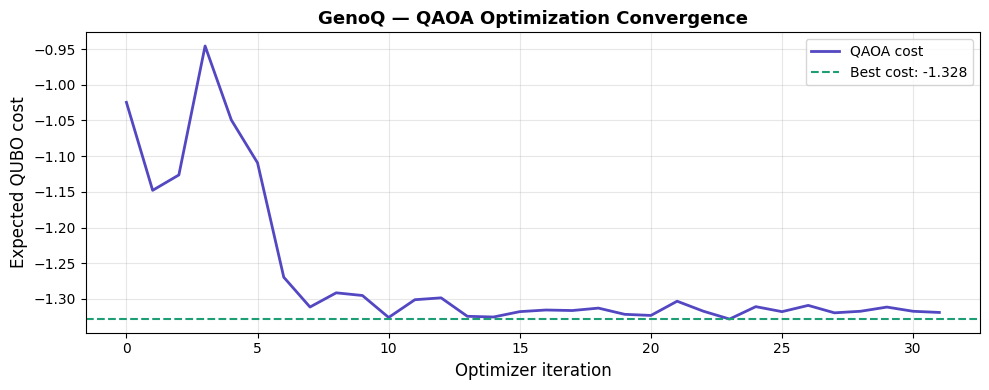

✅ Plot saved as genoq_optimization.png
📸 Take a screenshot of this chart for your demo video!


In [12]:
plt.figure(figsize=(10, 4))
plt.plot(cost_history_real, color="#5347C2", linewidth=2, label="QAOA cost")
plt.axhline(y=min(cost_history_real), color="#1D9E75",
            linestyle="--", linewidth=1.5,
            label=f"Best cost: {min(cost_history_real):.3f}")
plt.xlabel("Optimizer iteration", fontsize=12)
plt.ylabel("Expected QUBO cost", fontsize=12)
plt.title("GenoQ — QAOA Optimization Convergence", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("genoq_optimization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved as genoq_optimization.png")
print("📸 Take a screenshot of this chart for your demo video!")

In [13]:
final_circuit = build_qaoa_circuit(
    Q_real, result_real.x[0], result_real.x[1], N_QUBITS_REAL
)
compiled_final = transpile(final_circuit, simulator)
final_counts = simulator.run(compiled_final, shots=4096).result().get_counts()

best_bitstring = max(final_counts, key=final_counts.get)
best_x = np.array([int(b) for b in reversed(best_bitstring)])
selected_genes_real = [top_genes_real[i] for i, s in enumerate(best_x) if s == 1]

print("🏆 QAOA Final Gene Selection:")
print()
for i, selected in enumerate(best_x):
    gene = top_genes_real[i]
    status = "✅ SELECTED" if selected else "❌ Discarded"
    print(f"   {status} → {gene}  (MI Score: {top_mi_real[i]:.4f})")

print()
print(f"📌 Final selected genes : {selected_genes_real}")
print(f"   Selected {len(selected_genes_real)} out of {N_QUBITS_REAL} candidate genes")
print()
print("📸 Take a screenshot of this output for your demo video!")

🏆 QAOA Final Gene Selection:

   ✅ SELECTED → X95735_at  (MI Score: 0.5378)
   ✅ SELECTED → M55150_at  (MI Score: 0.4909)
   ✅ SELECTED → M27891_at  (MI Score: 0.4852)
   ✅ SELECTED → D10495_at  (MI Score: 0.4778)

📌 Final selected genes : ['X95735_at', 'M55150_at', 'M27891_at', 'D10495_at']
   Selected 4 out of 4 candidate genes

📸 Take a screenshot of this output for your demo video!


In [14]:
# Load test dataset
df_test = pd.read_csv("C:/Users/HP/Downloads/archive/data_set_ALL_AML_independent.csv")
cols_to_keep_test = ["Gene Accession Number"] + \
                    [col for col in df_test.columns
                     if col not in ["Gene Description", "Gene Accession Number"]
                     and "call" not in col.lower()]
df_test_clean = df_test[cols_to_keep_test].set_index("Gene Accession Number")
df_test_transposed = df_test_clean.T
df_test_transposed.index = df_test_transposed.index.astype(int)
df_test_final = df_test_transposed.copy()
df_test_final['diagnosis'] = df_labels['diagnosis']

# Prepare test arrays
X_test = df_test_final.drop(columns=["diagnosis"]).values
y_test = df_test_final["diagnosis"].values
X_test_scaled = scaler_real.transform(X_test)

print("✅ Test dataset loaded and prepared!")
print(f"   Test patients  : {X_test_scaled.shape[0]}")
print(f"   ALL patients   : {(y_test==0).sum()}")
print(f"   AML patients   : {(y_test==1).sum()}")

✅ Test dataset loaded and prepared!
   Test patients  : 34
   ALL patients   : 20
   AML patients   : 14


In [15]:
from sklearn.metrics import accuracy_score

results = {}

# QAOA
selected_indices = [gene_names_real.index(g) for g in selected_genes_real]
X_train_q = X_real_scaled[:, selected_indices]
X_test_q  = X_test_scaled[:, selected_indices]
clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf.fit(X_train_q, y_real)
results["QAOA (Quantum)"] = accuracy_score(y_test, clf.predict(X_test_q))

# SelectKBest
selector = SelectKBest(f_classif, k=4)
selector.fit(X_real_scaled, y_real)
clf2 = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf2.fit(selector.transform(X_real_scaled), y_real)
results["SelectKBest"] = accuracy_score(y_test, clf2.predict(selector.transform(X_test_scaled)))

# RF Importance
rf_sel = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_sel.fit(X_real_scaled, y_real)
top_rf = np.argsort(rf_sel.feature_importances_)[::-1][:4]
clf3 = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf3.fit(X_real_scaled[:, top_rf], y_real)
results["RF Importance"] = accuracy_score(y_test, clf3.predict(X_test_scaled[:, top_rf]))

# Lasso
lasso = LassoCV(cv=5, random_state=SEED, max_iter=10000)
lasso.fit(X_real_scaled, y_real)
lasso_idx = np.where(lasso.coef_ != 0)[0][:4]
if len(lasso_idx) > 0:
    clf4 = RandomForestClassifier(n_estimators=100, random_state=SEED)
    clf4.fit(X_real_scaled[:, lasso_idx], y_real)
    results["Lasso"] = accuracy_score(y_test, clf4.predict(X_test_scaled[:, lasso_idx]))
else:
    results["Lasso"] = 0.0

print("📊 Final Results — Quantum vs Classical:")
print()
print("┌─────────────────────────┬──────────┐")
print("│ Method                  │ Accuracy │")
print("├─────────────────────────┼──────────┤")
for method, acc in results.items():
    marker = "⚛️ " if "QAOA" in method else "   "
    print(f"│ {marker}{method:<22} │  {acc:.1%}   │")
print("└─────────────────────────┴──────────┘")

📊 Final Results — Quantum vs Classical:

┌─────────────────────────┬──────────┐
│ Method                  │ Accuracy │
├─────────────────────────┼──────────┤
│ ⚛️ QAOA (Quantum)         │  91.2%   │
│    SelectKBest            │  85.3%   │
│    RF Importance          │  94.1%   │
│    Lasso                  │  70.6%   │
└─────────────────────────┴──────────┘


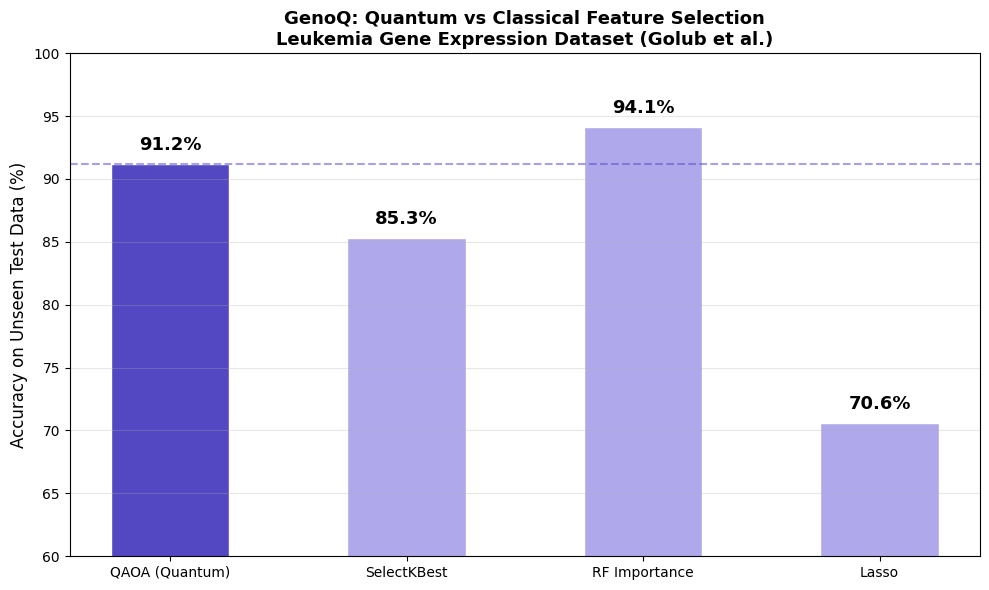

✅ Chart saved as genoq_comparison.png


In [17]:
methods = list(results.keys())
accuracies = [v * 100 for v in results.values()]
colors = ["#5347C2" if "QAOA" in m else "#AFA9EC" for m in methods]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, accuracies, color=colors,
              width=0.5, edgecolor="white")

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{acc:.1f}%",
            ha="center", va="bottom",
            fontsize=13, fontweight="bold")

ax.axhline(y=results["QAOA (Quantum)"] * 100,
           color="#5347C2", linestyle="--",
           linewidth=1.5, alpha=0.5)
ax.set_ylim(60, 100)
ax.set_ylabel("Accuracy on Unseen Test Data (%)", fontsize=12)
ax.set_title("GenoQ: Quantum vs Classical Feature Selection\n"
             "Leukemia Gene Expression Dataset (Golub et al.)",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("genoq_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved as genoq_comparison.png")
